--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:






# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt




In [2]:







# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código








In [3]:





# mostrar las primeras 5 filas de plans
plans.head()






,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:





# mostrar las primeras 5 filas de users
users.head()






,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:

# mostrar las primeras 5 filas de usage
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:






# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)







plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:





# inspección de plans con .info()
plans.info()






<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [7]:



# inspección de users con .info()
users.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:



# inspección de usage con .info()
usage.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:





# cantidad de nulos para users
print("users - valores nulos por columna:")
print(users.isna().sum())
print("users - proporción de nulos por columna:")
print(users.isna().mean())






users - valores nulos por columna:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
users - proporción de nulos por columna:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:



# cantidad de nulos para usage
print("usage - valores nulos por columna:")
print(usage.isna().sum())
print("usage - proporción de nulos por columna:")
print(usage.isna().mean())




usage - valores nulos por columna:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
usage - proporción de nulos por columna:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ Diagnóstico al final del bloque.

** PARA USERS**
- city: proporción intermedia (11.7%), se recomienda investigar y decidir si imputar o dejar nulos.
- churn_date: proporción muy alta (88.3%), lo más práctico es ignorar o eliminar la columna.

** PARA USAGE**
- (ejemplo) si alguna columna <5% → imputación sencilla;
- si entre 5–30% → investigar y posible imputación;
- si >80–90% → eliminar/ignorar columna.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:





# explorar columnas numéricas de users
print("Resumen estadístico de columnas numéricas en users:")
print(users.describe())






Resumen estadístico de columnas numéricas en users:
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id`  Va de 10000 a 13999, con 4000 registros en total.

- La columna `age`:

* Tiene valores entre -999 y 79.
* El mínimo (-999) es un valor claramente erróneo o marcador de dato faltante.
* La media es ~33.7 años, lo que refleja una población joven-adulta.
* La mayoría de los valores están entre 32 y 63 años, lo que parece razonable.    

In [13]:






# explorar columnas numéricas de usage
print("Resumen estadístico de columnas numéricas en usage:")
print(usage.describe())







Resumen estadístico de columnas numéricas en usage:
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`son identificadores id va del 1 al 40,000 y user id va de 10,000 a 13,999 lo que indica que hay 4,000 usuarios
  
- Las columnas:

Columna duration:
Representa tiempos de uso o duración de eventos.
- Tiene 17,924 registros válidos (faltan datos en comparación con el total de 40,000).
- La media es aprox 5.2, pero el máximo llega a 120, lo que sugiere valores atípicos.
- La mayoría de los valores están entre 1.4 y 7 (percentiles 25–75), lo que indica que los outliers podrían distorsionar el promedio.

Columna length:
Podría ser la longitud de sesiones, archivos o recorridos.
- Tiene 22,104 registros válidos (también con datos faltantes).
- La media es apox 52, pero el máximo llega a 1,490, lo que muestra gran dispersión.
- El rango intercuartílico (37–64) indica que la mayoría de los valores son moderados, aunque hay outliers muy grandes.



In [14]:





# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"Valores únicos en {col}:")
    print(users[col].unique())
    print(f"Frecuencia de cada valor en {col}:")
    print(users[col].value_counts())
    print("\n")








Valores únicos en city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Frecuencia de cada valor en city:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


Valores únicos en plan:
['Basico' 'Premium']
Frecuencia de cada valor en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64




La columna `city`:
- Contiene las ciudades donde se ubican los usuarios.
- Valores únicos: Bogotá, CDMX, Medellín, GDL, Cali, MTY, además de algunos registros con ? y valores faltantes (NaN).
Distribución:
- Bogotá es la ciudad con más usuarios (808).
- Le siguen CDMX (730), Medellín (616), GDL (450), Cali (424) y MTY (407).
- El valor ? aparece 96 veces, lo que indica datos incompletos o mal registrados.

Observación: conviene limpiar los valores ? y los NaN para mejorar la calidad del análisis.

La columna `plan`:
- Representa el tipo de plan contratado por los usuarios.
- Valores únicos: Básico y Premium.
Distribución:
- La mayoría de los usuarios tienen el plan Básico (2,595).
- Un grupo menor tiene el plan Premium (1,405).

Observación: esta columna es útil para segmentar usuarios según su nivel de servicio y comparar patrones de uso entre planes.


In [15]:






# explorar columna categórica de usage
print("Valores únicos en type:")
usage['type'].unique() # completa el código
print("Frecuencia de cada valor en type:")
print(usage['type'].value_counts())








Valores únicos en type:
Frecuencia de cada valor en type:
text    22092
call    17908
Name: type, dtype: int64


La columna `type` representa el tipo de uso registrado en el dataset.

Valores únicos: solo aparecen dos categorías:
- text → 22,092 registros
- call → 17,908 registros

Distribución:

- Los eventos de tipo text son más frecuentes que los de tipo call, con una diferencia de alrededor de 4,000 registros.
- Esto sugiere que los usuarios utilizan más los mensajes de texto que las llamadas dentro del periodo analizado.

Interpretación:
- Es una variable categórica binaria que clasifica el tipo de interacción.
- Puede ser muy útil para comparar patrones de duración, longitud o frecuencia según el tipo de uso.
- La diferencia en volumen entre text y call puede reflejar tendencias de comportamiento de los usuarios (por ejemplo, preferencia por mensajería sobre llamadas).


---
✍️ **Comentario**: Incluye observación qué ves y que acción se recomendara en cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Columna "city"

Qué veo:
- Contiene valores válidos como Bogotá, CDMX, Medellín, GDL, Cali, MTY.
- También aparecen valores inválidos: ? y NaN (faltantes).

Acción recomendada:
- Reemplazar ? por NaN para unificar los valores faltantes.

Decidir una estrategia de imputación o eliminación:
- Si el análisis requiere ubicación precisa, eliminar registros con NaN.
- Si no, se puede agruparlos en una categoría “Desconocido”.

Columna "Plan"
Qué veo:
- Solo dos valores válidos: Básico y Premium.
- No hay valores inválidos ni sentinels.

Acción recomendada:
- No requiere limpieza.
- Se puede usar directamente para segmentar usuarios.
- Verificar consistencia de escritura (ej. evitar variaciones como “basico” sin tilde).

Columna "type"

Qué veo:
- Dos categorías válidas: text y call.
- No hay valores inválidos ni sentinels.

Acción recomendada:
- No requiere limpieza.
- Puede usarse para análisis comparativos (ej. frecuencia de uso, duración de llamadas vs. longitud de textos).


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:




# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') 
# completa el código




In [17]:




# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código





In [18]:




# Revisar los años presentes en `reg_date` de users
print("Años en reg_date de users:")
print(users['reg_date'].dt.year.value_counts().sort_index())






Años en reg_date de users:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date:

Años válidos:
- 2022: 1,314 registros
- 2023: 1,316 registros
- 2024: 1,330 registros

Año inválido:
- 2026 → 40 registros

Diagnóstico:
- Los años 2022, 2023 y 2024 son consistentes con el rango esperado (hasta 2024).
- El año 2026 es un valor imposible, ya que es el año que apenas esta corriendo por eso no tiene los datos completos.

Acción recomendada:
- Identificar los registros con año 2026 y decidir si se eliminan o corrigen.
- Lo más seguro es excluirlos del análisis para evitar sesgos, ya que no se pueden llenar hasta que el año termine y evitariamos sesgos.


In [19]:




# Revisar los años presentes en `date` de usage
print("Años en date de usage:")
print(usage['date'].dt.year.value_counts().sort_index())





Años en date de usage:
2024.0    39950
Name: date, dtype: int64


En `date`:
2024: con 39,950 registros.

Valor inválido:
- Aparece un año extraño representado como 39950. Esto no corresponde a un año real y claramente es un error de registro o de conversión.

Diagnóstico:
- La mayoría de los datos están correctamente en 2024, lo cual es consistente con el rango esperado (hasta 2024).
- El valor 39950 es imposible y debe considerarse un dato inválido o un error de parsing.

Acción recomendada:
- Identificar los registros con año 39950 y revisarlos.
- Lo más seguro es convertirlos en NaT (valores nulos de fecha) para no sesgar el análisis.
- Basar el análisis únicamente en los registros válidos (2024), ya que son la gran mayoría y están dentro del rango esperado.


✍️ **Comentario**: diagnóstico, y **qué acción se recomienda** para cada caso.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Para reg_date
Acción recomendada:
- Identificar los registros con año 2026 y decidir si se eliminan o corrigen.
- Lo más seguro es excluirlos del análisis para evitar sesgos, ya que no se pueden llenar hasta que el año termine y evitariamos sesgos.

Para date:
Acción recomendada:
- Identificar los registros con año 39950 y revisarlos.
- Lo más seguro es convertirlos en NaT (valores nulos de fecha) para no sesgar el análisis.
- Basar el análisis únicamente en los registros válidos (2024), ya que son la gran mayoría y están dentro del rango esperado.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.


**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.


In [20]:



# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)


# Verificar cambios
users['age'].describe()




count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:



# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))




Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [22]:




# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT


# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())






2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:



# Verificación MAR en usage (Missing At Random) para duration
print("Nulos en duration por type:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))





Nulos en duration por type:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [24]:



# Verificación MAR en usage (Missing At Random) para length
print("\nNulos en length por type:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))





Nulos en length por type:
type
call    0.99933
text    0.00000
Name: length, dtype: float64


Diagnostico de nulos en `duration`: 

- Para registros de tipo call, la proporción de nulos en duration es 0.0 → no hay valores faltantes.
- Para registros de tipo text, la proporción de nulos en duration es ≈ 99.93% → prácticamente todos los textos no tienen duración registrada.
  
Interpretación:

- Esto confirma que los nulos en duration dependen directamente de la columna type.
- Los mensajes de texto no tienen una duración en segundos, por lo que el valor nulo es natural y esperado.
- Los nulos no son aleatorios, sino MAR (Missing At Random), ya que están condicionados por el tipo de evento.

Acción recomendada:
- Dejar los nulos como están, porque reflejan la naturaleza del dato (los textos no tienen duración).
- No se deben imputar ni eliminar, ya que hacerlo introduciría ruido o sesgo en el análisis.
- En futuros análisis, conviene tratar duration únicamente en registros de tipo call, y length únicamente en registros de tipo text.


y `length`:

- Para registros de tipo call, la proporción de nulos en length es ≈ 99.93% → prácticamente todas las llamadas no tienen longitud registrada.
- Para registros de tipo text, la proporción de nulos en length es 0.0 → ningún mensaje de texto tiene valores faltantes en longitud.
  
Interpretación:

- Los nulos en length dependen directamente de la columna type.
- Las llamadas no tienen longitud en caracteres, por lo que el valor nulo es natural y esperado.
- Esto confirma que los nulos son MAR (Missing At Random), ya que están condicionados por el tipo de evento.

Acción recomendada:
- Dejar los nulos como están, porque reflejan la naturaleza del dato (las llamadas no tienen longitud).
- No se deben imputar ni eliminar, ya que hacerlo introduciría ruido o sesgo en el análisis.
- En futuros análisis, conviene trabajar con length únicamente en registros de tipo text, y con duration únicamente en registros de tipo call.

En conjunto, tanto duration como length muestran un patrón claro de MAR, y la mejor práctica es mantener los nulos para preservar la lógica del dataset.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:



# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
    .agg({
        "is_text": "sum",          # total de mensajes
        "is_call": "sum",          # total de llamadas
        "duration": "sum"          # total de minutos de llamadas
    })
    .reset_index()
)

# observar resultado
usage_agg.head(3)




,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:




# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

# observar resultado
usage_agg.head(3)





,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:


# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users, on='user_id', how='left')
user_profile.head(5)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:


# Resumen estadístico de las columnas numéricas
resumen = user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()
print(resumen)

# Mediana de cada columna numérica
medianas = user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].median()
print(medianas)




       cant_mensajes  cant_llamadas  cant_minutos_llamada
count    3999.000000    3999.000000           3999.000000
mean        5.524381       4.478120             23.317054
std         2.358416       2.144238             18.168095
min         0.000000       0.000000              0.000000
25%         4.000000       3.000000             11.120000
50%         5.000000       4.000000             19.780000
75%         7.000000       6.000000             31.415000
max        17.000000      15.000000            155.690000
cant_mensajes            5.00
cant_llamadas            4.00
cant_minutos_llamada    19.78
dtype: float64


In [30]:


# Distribución porcentual del tipo de plan
distribucion_plan = user_profile['plan'].value_counts(normalize=True) * 100
print(distribucion_plan)




Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  


Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 



Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

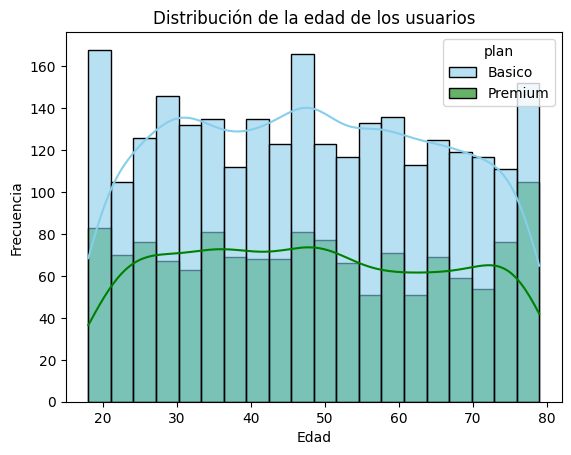

In [31]:


# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    kde=True,
    alpha=0.6
)

plt.title('Distribución de la edad de los usuarios')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: 
Distribución: La mayoría de los usuarios se concentran entre los 25 y 45 años, lo que indica que la base de clientes es relativamente joven-adulta.

Comparación por plan:
- El plan Básico (skyblue) tiene mayor presencia en los rangos más jóvenes (20–35 años).
- El plan Premium (verde) se concentra más en edades intermedias y mayores (35–55 años), mostrando que usuarios con más edad tienden a elegir el plan de mayor nivel.

Tendencia de densidad: 
La curva de densidad del plan Básico es más pronunciada en edades tempranas, mientras que la del Premium se extiende hacia edades más altas, sugiriendo que la preferencia por Premium aumenta con la edad.

Implicación de negocio:
- El plan Básico puede estar atrayendo a usuarios jóvenes que buscan opciones más económicas o están iniciando su experiencia con el servicio.
- El plan Premium parece captar usuarios con mayor edad, posiblemente porque valoran más beneficios adicionales o tienen mayor poder adquisitivo.

En resumen: los jóvenes prefieren el plan Básico, mientras que los adultos de mediana edad y mayores se inclinan hacia el Premium. Esto puede guiar estrategias de marketing diferenciadas según el rango de edad.


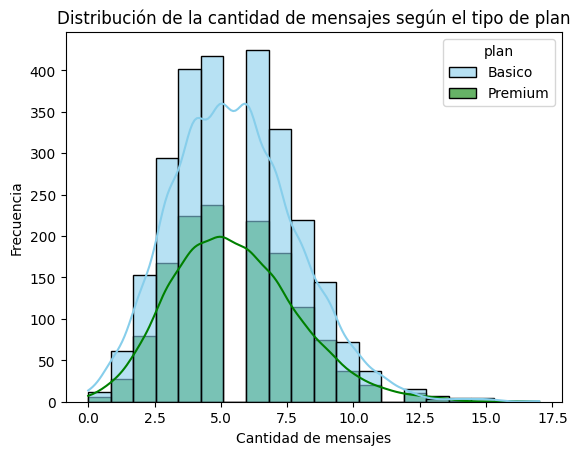

In [32]:


# Histograma para visualizar la cant_mensajes

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    kde=True,
    alpha=0.6
)

plt.title('Distribución de la cantidad de mensajes según el tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()





💡Insights: 
Distribución: La mayoría de los usuarios envía entre 3 y 10 mensajes, lo que refleja un comportamiento moderado en el uso de mensajería.

Comparación por plan:
- El plan Básico (skyblue) concentra más usuarios en los rangos bajos de mensajes (pocos envíos), lo que sugiere un uso más limitado.
- El plan Premium (verde) muestra una distribución más amplia, con presencia significativa en usuarios que envían muchos más mensajes, lo que indica un mayor nivel de interacción.

Tendencia de densidad: La curva del Premium se extiende hacia valores más altos, mientras que la del Básico se concentra en valores bajos. Esto sugiere que los usuarios Premium tienden a ser más activos en mensajería.

Implicación de negocio:
- El plan Básico parece atraer a usuarios con necesidades de comunicación más reducidas.
- El plan Premium está captando a los usuarios más intensivos en mensajería, lo que puede justificar el valor agregado del plan.

En resumen: los usuarios Premium envían más mensajes en promedio que los Básicos, lo que refuerza la idea de que quienes eligen Premium son más activos y probablemente valoran más las funcionalidades del servicio.


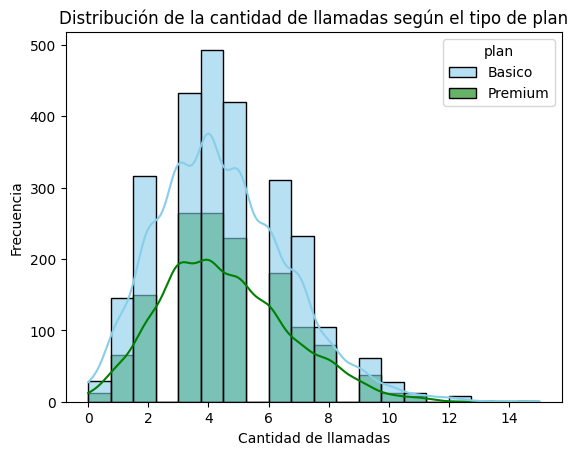

In [33]:


# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    kde=True,
    alpha=0.6
)

plt.title('Distribución de la cantidad de llamadas según el tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()




💡Insights: 
Distribución general: La mayoría de los usuarios realiza entre 2 y 6 llamadas, lo que refleja un uso moderado del servicio de llamadas.

Comparación por plan:
- El plan Básico (skyblue) muestra un mayor volumen de usuarios en los rangos bajos e intermedios de llamadas, con un pico claro alrededor de 4 llamadas.
- El plan Premium (verde) tiene una distribución más contenida, con menos usuarios en los rangos altos de llamadas, lo que sugiere que los Premium no destacan por hacer más llamadas.

Tendencia de densidad: 
La curva del Básico es más alta y más ancha, indicando que los usuarios de este plan tienden a hacer más llamadas en promedio. La curva del Premium es más baja y concentrada, lo que refleja un comportamiento más homogéneo y menos intensivo en llamadas.

Implicación de negocio:
- El plan Básico parece atraer a usuarios que dependen más de las llamadas, quizá porque buscan un plan económico pero con suficiente acceso a voz.
- El plan Premium podría estar orientado a usuarios que priorizan otros beneficios (como mensajería o minutos de calidad) más que la cantidad de llamadas.

En resumen: los usuarios del plan Básico realizan más llamadas en promedio que los Premium, lo que sugiere que la elección del plan está relacionada con distintos patrones de uso del servicio.


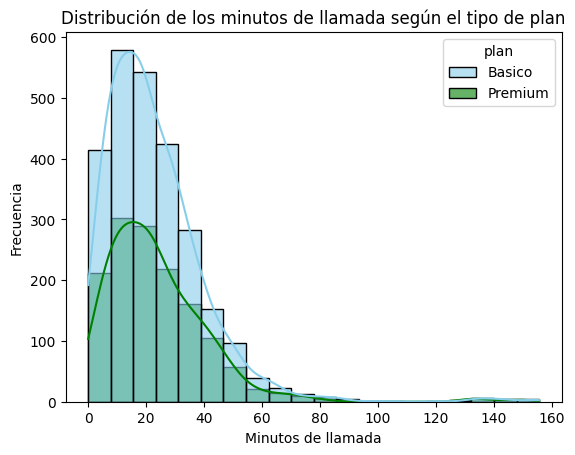

In [34]:


# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    kde=True,
    alpha=0.6
)

plt.title('Distribución de los minutos de llamada según el tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()




💡Insights: 
Distribución general: L
La mayoría de las llamadas son de corta duración (menos de 30 minutos), lo que se refleja en la alta concentración de barras al inicio del eje. La distribución es claramente sesgada hacia la derecha (right-skewed), con una larga cola de llamadas más extensas.

Comparación por plan:
- El plan Básico (skyblue) muestra mayor frecuencia en los rangos bajos de minutos, indicando que sus usuarios suelen realizar llamadas cortas.
- El plan Premium (verde), aunque menos frecuente en los rangos bajos, se extiende más hacia llamadas de mayor duración, lo que sugiere que los usuarios Premium tienden a sostener conversaciones más largas.

Tendencia de densidad: La curva del Básico es más alta en los primeros minutos y cae rápidamente, mientras que la del Premium se mantiene más estable y con una cola más larga, reflejando mayor variabilidad en la duración de las llamadas.

Implicación de negocio:
- Los usuarios del plan Básico parecen usar las llamadas de manera breve y funcional.
- Los usuarios del plan Premium aprovechan más los beneficios del plan para realizar llamadas prolongadas, lo que puede estar relacionado con mayor necesidad de comunicación o con el valor agregado que perciben en su suscripción.

En resumen: los Básicos hacen llamadas más cortas y frecuentes, mientras que los Premium tienden a realizar llamadas más largas, lo que refuerza la idea de distintos patrones de uso según el tipo de plan.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

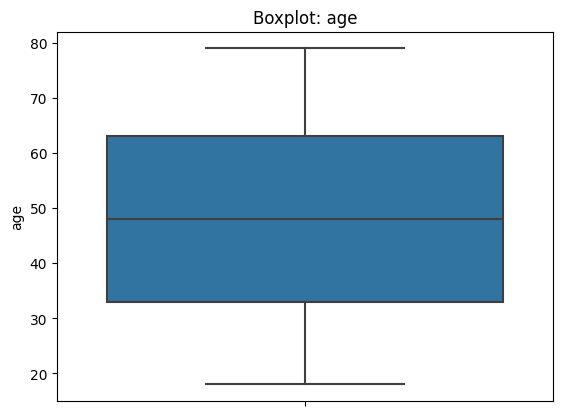

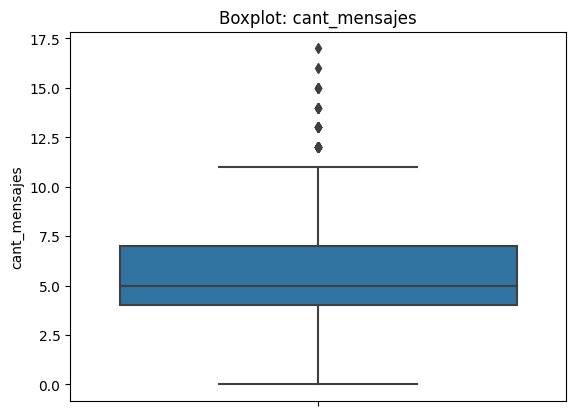

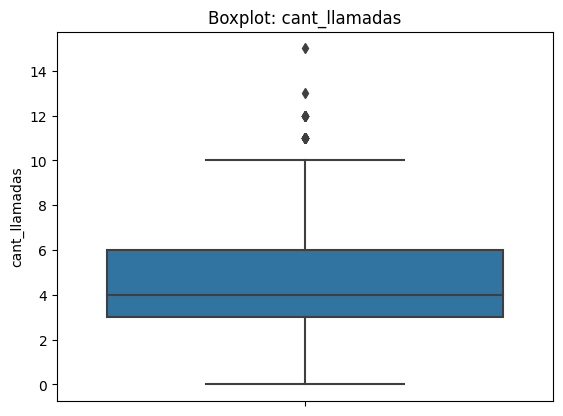

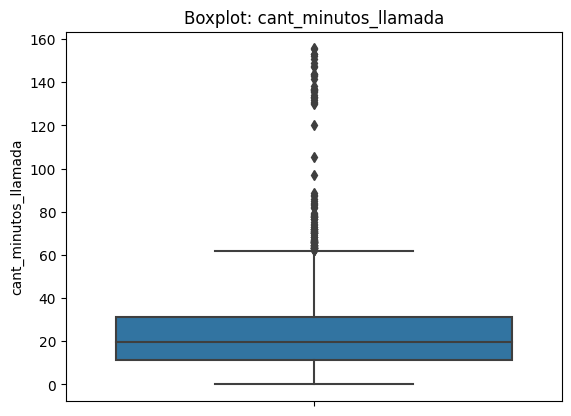

In [35]:


# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, y=col)
    plt.title(f'Boxplot: {col}')
    plt.show()




💡Insights: 
- Age: No se observan puntos fuera de los bigotes, por lo que no existen outliers en la variable age. El 50% de los usuarios se encuentra aproximadamente entre los 35 y 65 años aprox, mostrando que la base de clientes es principalmente de adultos en edad laboral.

- cant_mensajes: -
- Sí existen outliers en el extremo superior, con usuarios que envían entre 11 pasado los 14 mensajes, muy por encima del rango típico.
- La mediana está en 5 mensajes, lo que indica que la mayoría de los usuarios envía una cantidad moderada de mensajes.
- la mayoría envía pocos mensajes, pero existe un grupo reducido de usuarios que envía muchos más, generando outliers superiores.

cant_llamadas:
- Sí existen outliers en el extremo superior, con valores entre 11 y 15 llamadas, muy por encima del rango típico.
- La mediana está en 4 llamadas, lo que indica que la mayoría de los usuarios realiza pocas llamadas.


- cant_minutos_llamada:
- Sí existen numerosos outliers en el extremo superior, con llamadas que superan los 60 minutos y llegan hasta valores cercanos a 160 minutos.
- La mediana está en torno a 20 minutos, lo que indica que la mayoría de las llamadas son relativamente cortas.


In [36]:

# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Diccionario para guardar límites
columnas_limites = {}

# Calcular límites con IQR para cada columna
for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Límites
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    columnas_limites[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_limit': lower_limit,
        'upper_limit': upper_limit,
        'max': user_profile[col].max(),
        'min': user_profile[col].min()
    }

# Mostrar resultados
for col, valores in columnas_limites.items():
    print(f"{col}:")
    print(f"  Q1 = {valores['Q1']:.2f}, Q3 = {valores['Q3']:.2f}, IQR = {valores['IQR']:.2f}")
    print(f"  Límite inferior = {valores['lower_limit']:.2f}, Límite superior = {valores['upper_limit']:.2f}")
    print(f"  Min real = {valores['min']}, Max real = {valores['max']}")
    
    if valores['max'] > valores['upper_limit']:
        print("  → Hay outliers superiores.\n")
    elif valores['min'] < valores['lower_limit']:
        print("  → Hay outliers inferiores.\n")
    else:
        print("  → No se detectan outliers.\n")





age:
  Q1 = 33.00, Q3 = 63.00, IQR = 30.00
  Límite inferior = -12.00, Límite superior = 108.00
  Min real = 18.0, Max real = 79.0
  → No se detectan outliers.

cant_mensajes:
  Q1 = 4.00, Q3 = 7.00, IQR = 3.00
  Límite inferior = -0.50, Límite superior = 11.50
  Min real = 0, Max real = 17
  → Hay outliers superiores.

cant_llamadas:
  Q1 = 3.00, Q3 = 6.00, IQR = 3.00
  Límite inferior = -1.50, Límite superior = 10.50
  Min real = 0, Max real = 15
  → Hay outliers superiores.

cant_minutos_llamada:
  Q1 = 11.12, Q3 = 31.41, IQR = 20.30
  Límite inferior = -19.32, Límite superior = 61.86
  Min real = 0.0, Max real = 155.69
  → Hay outliers superiores.



In [37]:


# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()



,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
cant_mensajes:
- Los outliers están en el extremo superior (usuarios que envían más de 11.5 mensajes, llegando hasta 17).
- Decisión: conviene mantenerlos, porque representan un comportamiento real de usuarios muy activos en mensajería. No parecen errores de captura, sino un segmento intensivo que puede ser útil para análisis de segmentación o marketing.

cant_llamadas: 
- Los outliers aparecen en el extremo superior (más de 10.5 llamadas, llegando hasta 15).
- Decisión: también es recomendable mantenerlos, ya que reflejan usuarios con un patrón de uso intensivo de llamadas. Eliminarlos podría ocultar un grupo relevante de clientes que usan mucho el servicio.

cant_minutos_llamada: 
- Los outliers están en el extremo superior (más de 61.8 minutos, llegando hasta 155).
- Decisión: aquí depende del objetivo:
- Si se busca un dataset homogéneo para modelado estadístico, conviene capar los valores extremos al límite superior (61.8).
- Si el objetivo es entender comportamiento de usuarios, conviene mantenerlos, porque muestran un segmento que realiza llamadas muy largas, lo cual puede ser clave para estrategias de retención o planes Premium.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [38]:

# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'  # valor por defecto

user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'
user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'grupo_uso'] = 'Uso medio'



In [39]:

# verificar cambios
user_profile.head()


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:

# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'  

user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'
user_profile.loc[(user_profile['age'] >= 30) & (user_profile['age'] < 60), 'grupo_edad'] = 'Adulto'



In [41]:

# verificar cambios
user_profile.head()


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Uso medio,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

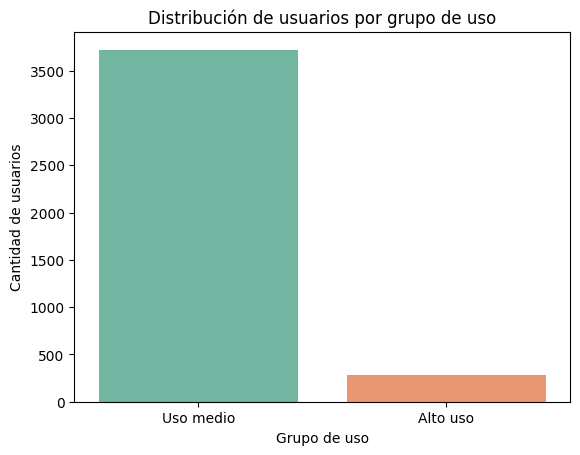

In [42]:

# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette='Set2')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()


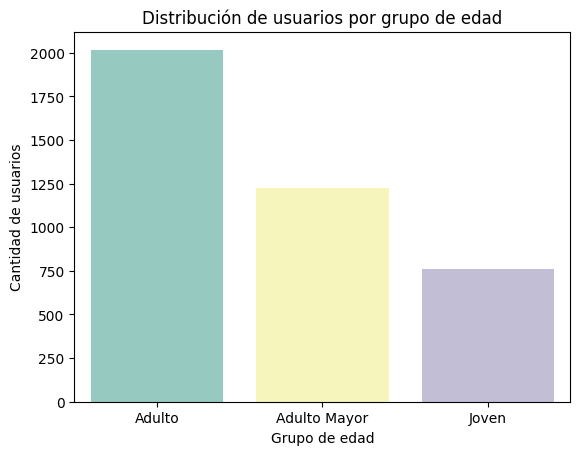

In [43]:

# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='Set3')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()




---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La columna churn_date tiene un 88.3% de nulos: se recomienda eliminarla.
- La columna city presenta valores inválidos (?) y nulos (~11.7%): conviene limpiar y decidir si imputar o agrupar en “Desconocido”.
- La columna age contiene un valor erróneo (-999):debe corregirse o eliminarse.
- En reg_date aparecen registros con año inválido (2026): excluirlos para evitar sesgos.
- En date aparece un valor imposible (39950):convertirlo en NaT.
- Variables duration y length muestran nulos dependientes del tipo de evento (MAR): mantenerlos, ya que reflejan la naturaleza del dato


🔍 **Segmentos por Edad**
- La mayoria de de usuarios se concentra entre 25 y 45 años: base joven - adulta.
- El plan básico predomina en usuaarios jóvenes (20 a 35 años).
- El plan premium se concentra en edades intermedias y mayores (35 a 55 años).

Se observa que la edad influye en la elección del plan, con Premium más atractivo para adultos con mayo poder adquisitivo.


📊 **Segmentos por Nivel de Uso**
- Mensajes: la mayoría envía entre 3 y 10; los Premium son más activos y generan outliers superiores (>11).
- Llamadas: la mayoría realiza entre 2 y 6; los Básicos destacan por mayor volumen, con outliers superiores (>10).
- Minutos de llamada: la mayoría dura <30 min; los Premium realizan llamadas más largas, con outliers superiores (>60 min)
- Implicación: los patrones de uso difieren según el plan: Básico más orientado a llamadas cortas y frecuentes, Premium a mensajes y llamadas largas




➡️ Esto sugiere que:
- Los usuarios jóvenes prefieren planes económicos y de uso limitado.
- Los usuarios adultos valoran mas beneficios y tienden a elegir el Premium.
- Los outliers superiores en mensajes, llamadas y minutos reflejan segmentos intensivos que pueden ser clave para estrategias de retención y ventas más caras.


💡 **Recomendaciones**
- Limpieza de datos: eliminar columnas con alta proporción de nulos (churn_date), corregir valores inválidos en city, reg_date y date.

Segmentación de clientes: diseñar estrategias diferenciadas:

- Jóvenes → planes económicos y promociones de entrada.
- Adultos → destacar beneficios Premium y valor agregado.

Análisis de outliers: 
- mantenerlos en mensajes y llamadas para identificar usuarios intensivos; capar minutos de llamada si el objetivo es modelado estadístico.
- Marketing: aprovechar la relación entre edad y plan para campañas dirigidas según perfil demográfico y nivel de uso.


Link a repositorio público del proyecto: `LINK a tu repo aquí`